# Simulated Annealing — Final Thesis Run (20 Epochs)

**Bachelor Thesis — Differential Privacy for Medical Data**  
**German University in Cairo | Media Engineering Technology**

This is the **thesis-quality SA run** using 20 epochs per evaluation.

| Setting | Exploratory Run | This Final Run | Reason |
|---|---|---|---|
| Epochs per eval | 3 | **20** | Proper model convergence |
| Search range | [0.5, 20.0] | **[0.5, 3.0]** | Consensus: optimal ε ∈ [0.5, 1.2] |
| N_ITERATIONS | 15 | **10** | 20 epochs × 11 evals ≈ 3.5 hours |
| Sigma (perturbation) | 3.0 | **0.5** | Proportional to narrowed range |
| Validation fold | 9 | **9** | Used during SA search |
| Final evaluation | — | **Fold 10** | Standard PTB-XL test set |

**Purpose:** Verify whether SA still converges to the same optimal epsilon when evaluated properly with 20 epochs.  
If SA finds a similar ε to the 3-epoch run, it confirms the result is robust. If it changes, the 20-epoch result takes precedence.

### Setup on Kaggle:
1. Add **PTB-XL dataset** (khyeh0719) as input
2. Set accelerator to **GPU T4 x2**
3. Run All — do not run individual cells
4. **If interrupted:** Run All again — notebook resumes from last checkpoint

## Cell 1 — Install Dependencies

In [1]:
!pip install opacus==1.4.0 wfdb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 5.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.8 MB/s eta 0:00:00


## Cell 2 — Imports & Configuration

In [2]:
import os, gc, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.metrics import roc_auc_score

import wfdb
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
RESULTS_DIR = "/kaggle/working/sa_final_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ─── MODEL / TRAINING ─────────────────────────────────────────────────────────
DELTA         = 1e-5
MAX_GRAD_NORM = 1.0
EPOCHS        = 20       # ← INCREASED from 3
BATCH_SIZE    = 32
MAX_PHY_BATCH = 32
LR            = 1e-3
N_CLASSES     = 5
SEED          = 42

# ─── FITNESS ──────────────────────────────────────────────────────────────────
PRIVACY_WEIGHT = 0.3     # 70% AUROC + 30% privacy  (same as BO final run)
EPS_SCALE      = 20.0    # privacy_score = 1 - epsilon / EPS_SCALE

# ─── SA SETTINGS ──────────────────────────────────────────────────────────────
EPS_MIN      = 0.5
EPS_MAX      = 3.0       # narrowed from 20.0 — all methods agree optimum is here
SIGMA        = 0.5       # Gaussian perturbation std (proportional to [0.5,3.0] range)
T_START      = 0.02      # initial temperature (scaled to narrowed fitness landscape)
T_END        = 0.001
ALPHA        = 0.80      # geometric cooling
N_ITERATIONS = 10        # 11 total evals max, ~3.5 hours at 20 epochs each

# ─── FOLD SETTINGS ────────────────────────────────────────────────────────────
TRAIN_FOLDS = list(range(1, 9))
VAL_FOLD    = 9
TEST_FOLD   = 10

# ─── REFERENCE VALUES ─────────────────────────────────────────────────────────
BASELINE_AUROC = 0.9318
SA_3EPOCH_EPS  = 0.8658   # best fitness from 3-epoch exploratory SA run
BO_FINAL_EPS   = 0.9782   # BO final run (20 epochs, 70/30 fitness)

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

temps = [T_START * (ALPHA ** i) for i in range(N_ITERATIONS + 1)]
print(f"Device        : {DEVICE}")
print(f"EPOCHS/eval   : {EPOCHS}")
print(f"Iterations    : {N_ITERATIONS} (+ 1 init = {N_ITERATIONS+1} max evals)")
print(f"Search range  : ε ∈ [{EPS_MIN}, {EPS_MAX}]")
print(f"Sigma         : {SIGMA}")
print(f"Temperature   : {T_START} → {temps[-1]:.5f} (alpha={ALPHA})")
print(f"Fitness       : {int((1-PRIVACY_WEIGHT)*100)}% AUROC + {int(PRIVACY_WEIGHT*100)}% privacy")
print(f"Est. runtime  : ~{(N_ITERATIONS+1) * EPOCHS * 1.5 / 60:.1f}–{(N_ITERATIONS+1) * EPOCHS * 2.0 / 60:.1f} hours")

Device        : cuda
EPOCHS/eval   : 20
Iterations    : 10 (+ 1 init = 11 max evals)
Search range  : ε ∈ [0.5, 3.0]
Sigma         : 0.5
Temperature   : 0.02 → 0.00215 (alpha=0.8)
Fitness       : 70% AUROC + 30% privacy
Est. runtime  : ~5.5–7.3 hours


## Cell 3 — Load PTB-XL Metadata

In [3]:
import ast

ptbxl_db  = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
scp_codes = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)
ptbxl_db['scp_codes'] = ptbxl_db['scp_codes'].apply(ast.literal_eval)
scp_codes = scp_codes[scp_codes['diagnostic'] == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_superclass_labels(scp_dict):
    labels = np.zeros(N_CLASSES, dtype=np.float32)
    for code, likelihood in scp_dict.items():
        if likelihood >= 100 and code in scp_codes.index:
            superclass = scp_codes.loc[code, 'diagnostic_class']
            if superclass in SUPERCLASSES:
                labels[SUPERCLASSES.index(superclass)] = 1.0
    return labels

ptbxl_db['label_vec'] = ptbxl_db['scp_codes'].apply(get_superclass_labels)
ptbxl_db = ptbxl_db[ptbxl_db['label_vec'].apply(lambda x: x.sum() > 0)].copy()

train_df = ptbxl_db[ptbxl_db['strat_fold'].isin(TRAIN_FOLDS)].copy()
val_df   = ptbxl_db[ptbxl_db['strat_fold'] == VAL_FOLD].copy()
test_df  = ptbxl_db[ptbxl_db['strat_fold'] == TEST_FOLD].copy()

print(f"Train (folds 1-8): {len(train_df)} records")
print(f"Val   (fold {VAL_FOLD}):   {len(val_df)} records  ← used during SA search")
print(f"Test  (fold {TEST_FOLD}):  {len(test_df)} records  ← final thesis result only")

Train (folds 1-8): 13826 records
Val   (fold 9):   1717 records  ← used during SA search
Test  (fold 10):  1716 records  ← final thesis result only


## Cell 4 — Shared Utilities (Dataset, Model, Evaluate)

In [4]:
class ECGDataset(Dataset):
    def __init__(self, df, data_root, sampling_freq=100):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.freq_col  = 'filename_lr' if sampling_freq == 100 else 'filename_hr'

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        fpath  = os.path.join(self.data_root, row[self.freq_col])
        record = wfdb.rdrecord(fpath)
        signal = record.p_signal.T
        signal = np.nan_to_num(signal, nan=0.0)
        mean   = signal.mean(axis=1, keepdims=True)
        std    = signal.std(axis=1, keepdims=True) + 1e-8
        signal = ((signal - mean) / std)[np.newaxis, :, :].astype(np.float32)
        return torch.from_numpy(signal), torch.from_numpy(row['label_vec'].astype(np.float32))


def make_loaders(train_df, val_df, test_df, data_root, batch_size=32):
    train_loader = DataLoader(ECGDataset(train_df, data_root), batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(ECGDataset(val_df,   data_root), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ECGDataset(test_df,  data_root), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


def replace_batchnorm(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            num_groups   = 32
            while num_channels % num_groups != 0:
                num_groups //= 2
            setattr(module, name, nn.GroupNorm(num_groups, num_channels))
        else:
            replace_batchnorm(child)
    return module


def build_model():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7,7), stride=(2,2), padding=(3,3), bias=False)
    model.fc    = nn.Linear(model.fc.in_features, N_CLASSES)
    return replace_batchnorm(model)


def evaluate(model, loader, criterion, device):
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            logits  = model(x)
            total_loss += criterion(logits, y).item() * x.size(0)
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.cpu().numpy())
    preds  = np.vstack(all_logits)
    labels = np.vstack(all_labels)
    return (total_loss / len(loader.dataset),
            roc_auc_score(labels, preds, average='macro'),
            roc_auc_score(labels, preds, average='micro'))

print("Utilities loaded.")
print("BatchNorm → GroupNorm replacement active (required for DP-SGD)")

Utilities loaded.
BatchNorm → GroupNorm replacement active (required for DP-SGD)


## Cell 5 — Fitness Function with Checkpoint/Resume

`fitness = 0.7 × AUROC + 0.3 × privacy_score`  
`privacy_score = 1 − ε / 20.0`

Results are **saved after every unique evaluation** to `sa_final_eval_log.csv`.  
If the kernel dies, Run All again — completed evaluations are reloaded from CSV.

In [5]:
CSV_LOG_PATH = os.path.join(RESULTS_DIR, 'sa_final_eval_log.csv')

# Load existing log if resuming
if os.path.exists(CSV_LOG_PATH):
    _existing    = pd.read_csv(CSV_LOG_PATH)
    eval_log     = _existing.to_dict('records')
    fitness_cache = {round(r['epsilon'], 3): {
        'auroc': r['auroc'], 'fitness': r['fitness'], 'privacy_score': r['privacy_score']
    } for r in eval_log if not r.get('cached', False)}
    print(f"RESUMED: loaded {len(eval_log)} log entries, {len(fitness_cache)} cached evaluations")
else:
    eval_log      = []
    fitness_cache = {}
    print("Fresh run: no existing log found")

search_start = time.time()

def evaluate_epsilon(epsilon, iteration, accepted=True):
    eps_key = round(epsilon, 3)

    if eps_key in fitness_cache:
        cached = fitness_cache[eps_key]
        print(f"  [cache] ε={epsilon:.4f} → AUROC={cached['auroc']:.4f} | Fitness={cached['fitness']:.4f}")
        eval_log.append({'iteration': iteration, 'epsilon': epsilon,
                         'auroc': cached['auroc'], 'fitness': cached['fitness'],
                         'privacy_score': cached['privacy_score'],
                         'accepted': accepted, 'cached': True})
        return cached['fitness']

    t_start = time.time()
    torch.cuda.empty_cache(); gc.collect()

    train_loader, val_loader, _ = make_loaders(train_df, val_df, test_df, DATA_PATH, BATCH_SIZE)
    model     = build_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    privacy_engine = PrivacyEngine(accountant='rdp')
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model, optimizer=optimizer, data_loader=train_loader,
        target_epsilon=epsilon, target_delta=DELTA,
        epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        with BatchMemoryManager(data_loader=train_loader,
                                max_physical_batch_size=MAX_PHY_BATCH,
                                optimizer=optimizer) as safe_loader:
            for x, y in safe_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                criterion(model(x), y).backward()
                optimizer.step()
        achieved_eps = privacy_engine.get_epsilon(DELTA)
        _, _, val_auroc = evaluate(model, val_loader, criterion, DEVICE)
        ep_time = (time.time() - t_start) / 60
        print(f"    Epoch {epoch:2d}/{EPOCHS} | Val AUROC: {val_auroc:.4f} | ε achieved: {achieved_eps:.3f} | {ep_time:.1f} min")

    _, _, final_auroc = evaluate(model, val_loader, criterion, DEVICE)
    privacy_score   = 1.0 - (epsilon / EPS_SCALE)
    composite_score = (1 - PRIVACY_WEIGHT) * final_auroc + PRIVACY_WEIGHT * privacy_score
    eval_time       = (time.time() - t_start) / 60

    print(f"  → ε={epsilon:.4f} | AUROC={final_auroc:.4f} | Privacy={privacy_score:.4f} | Fitness={composite_score:.4f} | {eval_time:.1f} min")

    fitness_cache[eps_key] = {'auroc': final_auroc, 'fitness': composite_score, 'privacy_score': privacy_score}
    eval_log.append({'iteration': iteration, 'epsilon': epsilon, 'auroc': final_auroc,
                     'fitness': composite_score, 'privacy_score': privacy_score,
                     'accepted': accepted, 'cached': False, 'eval_time_min': round(eval_time, 1)})

    # ── Checkpoint after every unique eval ────────────────────────────────────
    pd.DataFrame(eval_log).to_csv(CSV_LOG_PATH, index=False)
    print(f"  ✓ Checkpoint saved ({len(fitness_cache)} unique evals complete)")

    del model, optimizer, privacy_engine
    torch.cuda.empty_cache(); gc.collect()
    return composite_score

print("Fitness function ready.")
print(f"  Formula  : {int((1-PRIVACY_WEIGHT)*100)}% × AUROC + {int(PRIVACY_WEIGHT*100)}% × (1 − ε/20)")
print(f"  Checkpoint: {CSV_LOG_PATH}")

Fresh run: no existing log found
Fitness function ready.
  Formula  : 70% × AUROC + 30% × (1 − ε/20)
  Checkpoint: /kaggle/working/sa_final_results/sa_final_eval_log.csv


## Cell 6 — Run Simulated Annealing

> **⏱ Estimated time: 3.5–4 hours** on Kaggle T4 x2  
> 11 evaluations × 20 epochs × ~1.5–2 min/epoch ≈ 3.5 hours  
> Cache hits (revisited epsilon values) reduce this further.

**If interrupted:** Run All again — completed evaluations load from CSV automatically.

In [6]:
print("Starting Simulated Annealing — Final Thesis Run")
print("="*60)
print(f"Iterations   : {N_ITERATIONS} (+ 1 init = {N_ITERATIONS+1} max unique evals)")
print(f"Search range : ε ∈ [{EPS_MIN}, {EPS_MAX}]")
print(f"Epochs/eval  : {EPOCHS}")
print(f"Sigma        : {SIGMA}")
print(f"Temperature  : {T_START} → ~{T_START * ALPHA**N_ITERATIONS:.5f} (alpha={ALPHA})")
print(f"Fitness      : {int((1-PRIVACY_WEIGHT)*100)}% AUROC + {int(PRIVACY_WEIGHT*100)}% privacy")
print("="*60)

np.random.seed(SEED)

# ─── Initialisation ───────────────────────────────────────────────────────────
eps_current = float(np.exp(np.random.uniform(np.log(EPS_MIN), np.log(EPS_MAX))))
print(f"\nIteration 0 (init) | ε = {eps_current:.4f}")
fit_current  = evaluate_epsilon(eps_current, iteration=0)
best_eps     = eps_current
best_fitness = fit_current
T = T_START
n_accepted = 0; n_rejected = 0; n_uphill = 0

print(f"Initial solution: ε={eps_current:.4f} | Fitness={fit_current:.4f} | T={T:.4f}")

# ─── SA Main Loop ─────────────────────────────────────────────────────────────
for it in range(1, N_ITERATIONS + 1):
    elapsed = (time.time() - search_start) / 60
    print(f"\nIteration {it}/{N_ITERATIONS} | T={T:.5f} | ε_current={eps_current:.4f} | fit={fit_current:.4f} | {elapsed:.1f} min elapsed")

    eps_new = float(np.clip(eps_current + np.random.normal(0, SIGMA), EPS_MIN, EPS_MAX))
    print(f"  Proposed ε_new = {eps_new:.4f}  (Δ = {eps_new - eps_current:+.4f})")

    fit_new = evaluate_epsilon(eps_new, iteration=it)
    delta_f = fit_new - fit_current

    if delta_f > 0:
        accept = True
        print(f"  => ACCEPTED (improvement: ΔF={delta_f:+.4f})")
        n_accepted += 1
    else:
        prob = math.exp(delta_f / T)
        rand = np.random.random()
        accept = rand < prob
        if accept:
            print(f"  => ACCEPTED (uphill: ΔF={delta_f:+.4f} | P={prob:.4f} | rand={rand:.4f}) [SA exploration]")
            n_uphill += 1; n_accepted += 1
        else:
            print(f"  => REJECTED (ΔF={delta_f:+.4f} | P={prob:.4f} | rand={rand:.4f})")
            n_rejected += 1

    eval_log[-1]['accepted'] = accept

    if accept:
        eps_current = eps_new
        fit_current = fit_new

    if fit_new > best_fitness:
        best_fitness = fit_new
        best_eps     = eps_new
        print(f"  ** New best: ε={best_eps:.4f} | Fitness={best_fitness:.4f}")

    T *= ALPHA

# ─── Summary ──────────────────────────────────────────────────────────────────
best_cache   = fitness_cache[round(best_eps, 3)]
best_auroc   = best_cache['auroc']
best_privacy = best_cache['privacy_score']
n_unique     = len(fitness_cache)
total_time   = (time.time() - search_start) / 60

print(f"\n{'='*60}")
print(f" SA SEARCH COMPLETE")
print(f" Total search time  : {total_time:.1f} min ({total_time/60:.2f} hours)")
print(f" Optimal epsilon     : ε = {best_eps:.4f}")
print(f" AUROC (val fold 9)  : {best_auroc:.4f}")
print(f" Composite fitness   : {best_fitness:.4f}")
print(f" Privacy score       : {best_privacy:.4f}")
print(f" Unique evaluations  : {n_unique} | Accepted: {n_accepted} | Uphill: {n_uphill} | Rejected: {n_rejected}")
print(f"{'='*60}")
print(f"\n 3-epoch SA found   : ε = {SA_3EPOCH_EPS}")
print(f" 20-epoch SA found  : ε = {best_eps:.4f}")
print(f" BO final (20 ep)   : ε = {BO_FINAL_EPS}")
print(f" Difference SA vs BO: {abs(best_eps - BO_FINAL_EPS):.4f} ε units")

Starting Simulated Annealing — Final Thesis Run
Iterations   : 10 (+ 1 init = 11 max unique evals)
Search range : ε ∈ [0.5, 3.0]
Epochs/eval  : 20
Sigma        : 0.5
Temperature  : 0.02 → ~0.00215 (alpha=0.8)
Fitness      : 70% AUROC + 30% privacy

Iteration 0 (init) | ε = 0.9782


04/26/2026 17:34:26:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7283 | ε achieved: 0.578 | 1.5 min
    Epoch  2/20 | Val AUROC: 0.7418 | ε achieved: 0.601 | 2.5 min
    Epoch  3/20 | Val AUROC: 0.7991 | ε achieved: 0.622 | 3.5 min
    Epoch  4/20 | Val AUROC: 0.8231 | ε achieved: 0.643 | 4.5 min
    Epoch  5/20 | Val AUROC: 0.8209 | ε achieved: 0.664 | 5.5 min
    Epoch  6/20 | Val AUROC: 0.8394 | ε achieved: 0.684 | 6.4 min
    Epoch  7/20 | Val AUROC: 0.8359 | ε achieved: 0.705 | 7.4 min
    Epoch  8/20 | Val AUROC: 0.8422 | ε achieved: 0.726 | 8.4 min
    Epoch  9/20 | Val AUROC: 0.8512 | ε achieved: 0.747 | 9.3 min
    Epoch 10/20 | Val AUROC: 0.8454 | ε achieved: 0.767 | 10.3 min
    Epoch 11/20 | Val AUROC: 0.8494 | ε achieved: 0.788 | 11.3 min
    Epoch 12/20 | Val AUROC: 0.8457 | ε achieved: 0.809 | 12.3 min
    Epoch 13/20 | Val AUROC: 0.8538 | ε achieved: 0.829 | 13.3 min
    Epoch 14/20 | Val AUROC: 0.8548 | ε achieved: 0.850 | 14.2 min
    Epoch 15/20 | Val AUROC: 0.8405 | ε achieved: 0.871 | 15.2 min
    

04/26/2026 17:54:33:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.6969 | ε achieved: 0.192 | 1.0 min
    Epoch  2/20 | Val AUROC: 0.7186 | ε achieved: 0.209 | 1.9 min
    Epoch  3/20 | Val AUROC: 0.7231 | ε achieved: 0.225 | 2.9 min
    Epoch  4/20 | Val AUROC: 0.7207 | ε achieved: 0.242 | 3.9 min
    Epoch  5/20 | Val AUROC: 0.7323 | ε achieved: 0.259 | 4.8 min
    Epoch  6/20 | Val AUROC: 0.7614 | ε achieved: 0.276 | 5.8 min
    Epoch  7/20 | Val AUROC: 0.7759 | ε achieved: 0.292 | 6.8 min
    Epoch  8/20 | Val AUROC: 0.8166 | ε achieved: 0.309 | 7.8 min
    Epoch  9/20 | Val AUROC: 0.8087 | ε achieved: 0.326 | 8.7 min
    Epoch 10/20 | Val AUROC: 0.8304 | ε achieved: 0.342 | 9.7 min
    Epoch 11/20 | Val AUROC: 0.8130 | ε achieved: 0.358 | 10.7 min
    Epoch 12/20 | Val AUROC: 0.8241 | ε achieved: 0.374 | 11.6 min
    Epoch 13/20 | Val AUROC: 0.8346 | ε achieved: 0.390 | 12.6 min
    Epoch 14/20 | Val AUROC: 0.8224 | ε achieved: 0.406 | 13.6 min
    Epoch 15/20 | Val AUROC: 0.8317 | ε achieved: 0.421 | 14.6 min
    E

...

    Epoch  1/20 | Val AUROC: 0.7221 | ε achieved: 0.672 | 1.0 min
    Epoch  2/20 | Val AUROC: 0.7418 | ε achieved: 0.709 | 1.9 min
    Epoch  3/20 | Val AUROC: 0.8063 | ε achieved: 0.731 | 2.9 min
    Epoch  4/20 | Val AUROC: 0.8289 | ε achieved: 0.753 | 3.9 min
    Epoch  5/20 | Val AUROC: 0.8419 | ε achieved: 0.775 | 4.8 min
    Epoch  6/20 | Val AUROC: 0.8370 | ε achieved: 0.797 | 5.8 min
    Epoch  7/20 | Val AUROC: 0.8496 | ε achieved: 0.819 | 6.8 min
    Epoch  8/20 | Val AUROC: 0.8457 | ε achieved: 0.841 | 7.7 min
    Epoch  9/20 | Val AUROC: 0.8350 | ε achieved: 0.863 | 8.7 min
    Epoch 10/20 | Val AUROC: 0.8396 | ε achieved: 0.885 | 9.7 min
    Epoch 11/20 | Val AUROC: 0.8354 | ε achieved: 0.907 | 10.6 min
    Epoch 12/20 | Val AUROC: 0.8384 | ε achieved: 0.929 | 11.6 min
    Epoch 13/20 | Val AUROC: 0.8362 | ε achieved: 0.950 | 12.5 min
    Epoch 14/20 | Val AUROC: 0.8511 | ε achieved: 0.972 | 13.5 min
    Epoch 15/20 | Val AUROC: 0.8514 | ε achieved: 0.994 | 14.5 min
    E

04/26/2026 20:11:01:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7120 | ε achieved: 0.672 | 1.0 min
    Epoch  2/20 | Val AUROC: 0.7461 | ε achieved: 0.709 | 1.9 min
    Epoch  3/20 | Val AUROC: 0.7799 | ε achieved: 0.731 | 2.9 min
    Epoch  4/20 | Val AUROC: 0.8359 | ε achieved: 0.753 | 3.9 min
    Epoch  5/20 | Val AUROC: 0.8321 | ε achieved: 0.775 | 4.8 min
    Epoch  6/20 | Val AUROC: 0.8478 | ε achieved: 0.797 | 5.8 min
    Epoch  7/20 | Val AUROC: 0.8389 | ε achieved: 0.819 | 6.8 min
    Epoch  8/20 | Val AUROC: 0.8342 | ε achieved: 0.841 | 7.7 min
    Epoch  9/20 | Val AUROC: 0.8414 | ε achieved: 0.863 | 8.7 min
    Epoch 10/20 | Val AUROC: 0.8466 | ε achieved: 0.885 | 9.7 min
    Epoch 11/20 | Val AUROC: 0.8433 | ε achieved: 0.907 | 10.6 min
    Epoch 12/20 | Val AUROC: 0.8548 | ε achieved: 0.929 | 11.6 min
    Epoch 13/20 | Val AUROC: 0.8505 | ε achieved: 0.950 | 12.6 min
    Epoch 14/20 | Val AUROC: 0.8486 | ε achieved: 0.972 | 13.6 min
    Epoch 15/20 | Val AUROC: 0.8611 | ε achieved: 0.994 | 14.5 min
    E

04/26/2026 20:30:25:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


    Epoch  1/20 | Val AUROC: 0.7255 | ε achieved: 0.988 | 1.0 min
    Epoch  2/20 | Val AUROC: 0.7845 | ε achieved: 1.033 | 1.9 min
    Epoch  3/20 | Val AUROC: 0.8242 | ε achieved: 1.071 | 2.9 min
    Epoch  4/20 | Val AUROC: 0.8340 | ε achieved: 1.106 | 3.9 min
    Epoch  5/20 | Val AUROC: 0.8388 | ε achieved: 1.139 | 4.8 min
    Epoch  6/20 | Val AUROC: 0.8370 | ε achieved: 1.171 | 5.8 min
    Epoch  7/20 | Val AUROC: 0.8375 | ε achieved: 1.203 | 6.8 min
    Epoch  8/20 | Val AUROC: 0.8437 | ε achieved: 1.233 | 7.7 min
    Epoch  9/20 | Val AUROC: 0.8392 | ε achieved: 1.263 | 8.7 min
    Epoch 10/20 | Val AUROC: 0.8507 | ε achieved: 1.293 | 9.7 min
    Epoch 11/20 | Val AUROC: 0.8543 | ε achieved: 1.322 | 10.6 min
    Epoch 12/20 | Val AUROC: 0.8561 | ε achieved: 1.351 | 11.6 min
    Epoch 13/20 | Val AUROC: 0.8525 | ε achieved: 1.379 | 12.6 min
    Epoch 14/20 | Val AUROC: 0.8612 | ε achieved: 1.408 | 13.5 min
    Epoch 15/20 | Val AUROC: 0.8530 | ε achieved: 1.436 | 14.5 min
    E

## Cell 7 — Final Evaluation on Fold 10 (Thesis Result)

Train SA's best epsilon for **20 epochs** on folds 1–9, evaluate on **fold 10**.  
Fold 10 was **never seen during the SA search** — no data leakage.

In [7]:
print("="*60)
print(f" FINAL EVALUATION — FOLD 10 (Standard PTB-XL Test Set)")
print(f" Epsilon: {best_eps:.4f}  |  Epochs: {EPOCHS}")
print("="*60)

final_start = time.time()
torch.cuda.empty_cache(); gc.collect()

final_train_df = ptbxl_db[ptbxl_db['strat_fold'] <= 9].copy()
final_test_df  = ptbxl_db[ptbxl_db['strat_fold'] == TEST_FOLD].copy()
print(f" Final train set (folds 1-9): {len(final_train_df)} records")
print(f" Final test set  (fold 10)  : {len(final_test_df)} records")

final_train_loader = DataLoader(ECGDataset(final_train_df, DATA_PATH), batch_size=BATCH_SIZE,
                                shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
final_test_loader  = DataLoader(ECGDataset(final_test_df,  DATA_PATH), batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2, pin_memory=True)

final_model     = build_model().to(DEVICE)
final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = torch.optim.Adam(final_model.parameters(), lr=LR)

final_privacy = PrivacyEngine(accountant='rdp')
final_model, final_optimizer, final_train_loader = final_privacy.make_private_with_epsilon(
    module=final_model, optimizer=final_optimizer, data_loader=final_train_loader,
    target_epsilon=best_eps, target_delta=DELTA,
    epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
)

epoch_log = []
for epoch in range(1, EPOCHS + 1):
    final_model.train()
    with BatchMemoryManager(data_loader=final_train_loader,
                            max_physical_batch_size=MAX_PHY_BATCH,
                            optimizer=final_optimizer) as safe_loader:
        for x, y in safe_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            final_optimizer.zero_grad()
            final_criterion(final_model(x), y).backward()
            final_optimizer.step()
    achieved_eps = final_privacy.get_epsilon(DELTA)
    _, auroc_macro, auroc_micro = evaluate(final_model, final_test_loader, final_criterion, DEVICE)
    elapsed = (time.time() - final_start) / 60
    epoch_log.append({'epoch': epoch, 'auroc_macro': auroc_macro, 'auroc_micro': auroc_micro,
                      'eps_achieved': achieved_eps, 'elapsed_min': round(elapsed, 1)})
    print(f"  Epoch {epoch:2d}/{EPOCHS} | AUROC macro: {auroc_macro:.4f} | micro: {auroc_micro:.4f} | ε: {achieved_eps:.3f} | {elapsed:.1f} min")

final_time = (time.time() - final_start) / 60
_, final_auroc_macro, final_auroc_micro = evaluate(final_model, final_test_loader, final_criterion, DEVICE)
final_eps     = final_privacy.get_epsilon(DELTA)
privacy_score = 1.0 - (best_eps / EPS_SCALE)
final_fitness = (1 - PRIVACY_WEIGHT) * final_auroc_micro + PRIVACY_WEIGHT * privacy_score

print(f"\n{'='*60}")
print(f" THESIS RESULT — SA ε = {best_eps:.4f} (20 epochs, fold 10)")
print(f" AUROC macro : {final_auroc_macro:.4f}")
print(f" AUROC micro : {final_auroc_micro:.4f}   ← report this in thesis")
print(f" ε achieved  : {final_eps:.4f}")
print(f" δ           : {DELTA}")
print(f" Privacy score: {privacy_score:.4f}")
print(f" Composite fit: {final_fitness:.4f}")
print(f" No-DP baseline: {BASELINE_AUROC:.4f}")
print(f" Privacy cost  : {(BASELINE_AUROC - final_auroc_micro)*100:.2f}% AUROC reduction")
print(f" Evaluation time: {final_time:.1f} min")
print(f"{'='*60}")

 FINAL EVALUATION — FOLD 10 (Standard PTB-XL Test Set)
 Epsilon: 1.1079  |  Epochs: 20
 Final train set (folds 1-9): 15543 records
 Final test set  (fold 10)  : 1716 records


04/26/2026 20:49:51:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


  Epoch  1/20 | AUROC macro: 0.6997 | micro: 0.7266 | ε: 0.688 | 1.3 min
  Epoch  2/20 | AUROC macro: 0.7459 | micro: 0.7436 | ε: 0.709 | 2.4 min
  Epoch  3/20 | AUROC macro: 0.7824 | micro: 0.8007 | ε: 0.731 | 3.4 min
  Epoch  4/20 | AUROC macro: 0.7912 | micro: 0.8232 | ε: 0.753 | 4.5 min
  Epoch  5/20 | AUROC macro: 0.7922 | micro: 0.8118 | ε: 0.775 | 5.6 min
  Epoch  6/20 | AUROC macro: 0.7973 | micro: 0.8313 | ε: 0.797 | 6.7 min
  Epoch  7/20 | AUROC macro: 0.7951 | micro: 0.8326 | ε: 0.819 | 7.7 min
  Epoch  8/20 | AUROC macro: 0.7976 | micro: 0.8385 | ε: 0.841 | 8.8 min
  Epoch  9/20 | AUROC macro: 0.8033 | micro: 0.8460 | ε: 0.863 | 9.9 min
  Epoch 10/20 | AUROC macro: 0.8057 | micro: 0.8413 | ε: 0.885 | 11.0 min
  Epoch 11/20 | AUROC macro: 0.8105 | micro: 0.8373 | ε: 0.906 | 12.0 min
  Epoch 12/20 | AUROC macro: 0.8110 | micro: 0.8465 | ε: 0.928 | 13.1 min
  Epoch 13/20 | AUROC macro: 0.8119 | micro: 0.8526 | ε: 0.950 | 14.2 min
  Epoch 14/20 | AUROC macro: 0.8134 | micro: 0.

## Cell 8 — Plot Results

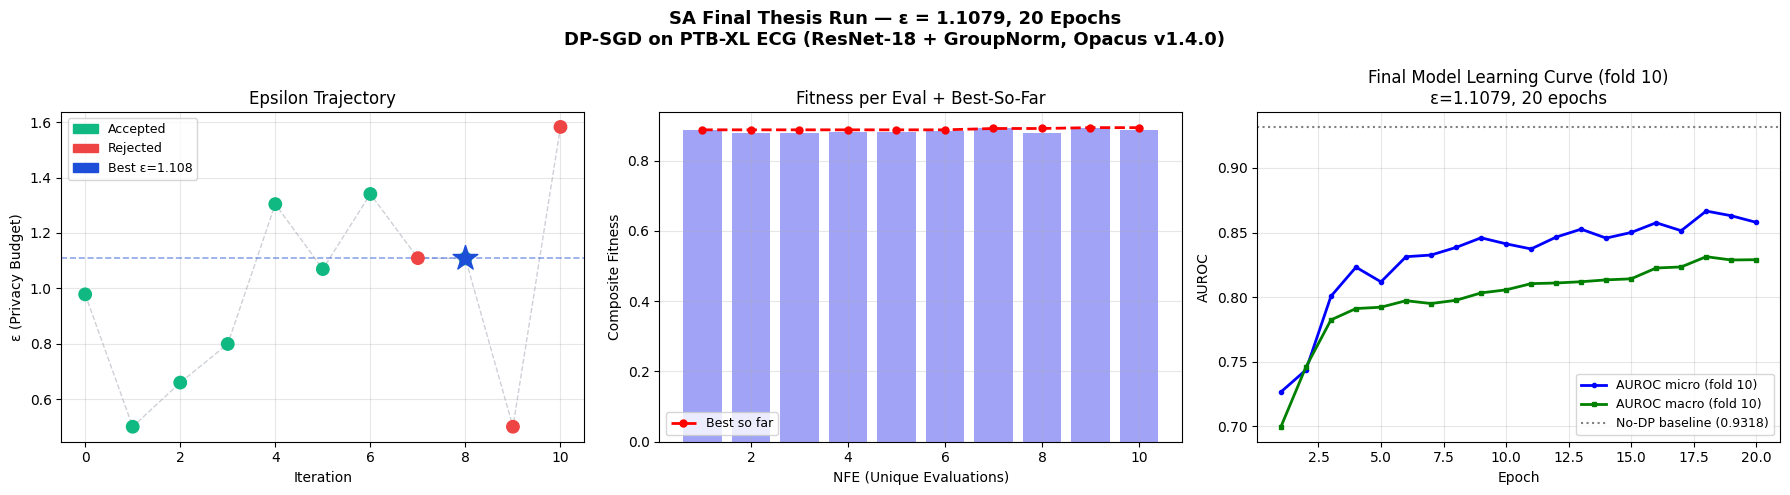

Plot saved: /kaggle/working/sa_final_results/sa_final_results.png


In [8]:
df_plot = pd.DataFrame(eval_log)
unique_df = df_plot[~df_plot['cached']].copy().reset_index(drop=True)
unique_df['nfe'] = range(1, len(unique_df) + 1)
unique_df['best_so_far'] = [unique_df['fitness'][:i+1].max() for i in range(len(unique_df))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'SA Final Thesis Run — ε = {best_eps:.4f}, {EPOCHS} Epochs\n'
             f'DP-SGD on PTB-XL ECG (ResNet-18 + GroupNorm, Opacus v1.4.0)',
             fontsize=13, fontweight='bold')

# Panel 1: epsilon trajectory
ax = axes[0]
colors = ['#10B981' if r['accepted'] else '#EF4444' for _, r in df_plot.iterrows()]
ax.plot(df_plot['iteration'], df_plot['epsilon'], '--', color='#9CA3AF', lw=1, alpha=0.5)
ax.scatter(df_plot['iteration'], df_plot['epsilon'], c=colors, s=80, zorder=5)
ax.scatter([df_plot[df_plot['epsilon'] == best_eps]['iteration'].values[0]], [best_eps],
           marker='*', color='#1D4ED8', s=350, zorder=6, label=f'SA best ε={best_eps:.3f}')
ax.axhline(y=best_eps, color='#1D4ED8', ls='--', lw=1.2, alpha=0.5)
green_p = mpatches.Patch(color='#10B981', label='Accepted')
red_p   = mpatches.Patch(color='#EF4444', label='Rejected')
ax.legend(handles=[green_p, red_p, mpatches.Patch(color='#1D4ED8', label=f'Best ε={best_eps:.3f}')], fontsize=9)
ax.set_xlabel('Iteration'); ax.set_ylabel('ε (Privacy Budget)')
ax.set_title('Epsilon Trajectory'); ax.grid(True, alpha=0.3)

# Panel 2: convergence (best-so-far vs NFE)
ax2 = axes[1]
ax2.bar(unique_df['nfe'], unique_df['fitness'], color=['#6366F1']*len(unique_df), alpha=0.6)
ax2.plot(unique_df['nfe'], unique_df['best_so_far'], 'r--o', lw=2, ms=5, label='Best so far')
ax2.set_xlabel('NFE (Unique Evaluations)'); ax2.set_ylabel('Composite Fitness')
ax2.set_title('Fitness per Eval + Best-So-Far'); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# Panel 3: final model learning curve
ax3 = axes[2]
ep_df = pd.DataFrame(epoch_log)
ax3.plot(ep_df['epoch'], ep_df['auroc_micro'], 'b-o', ms=3, lw=2, label='AUROC micro (fold 10)')
ax3.plot(ep_df['epoch'], ep_df['auroc_macro'], 'g-s', ms=3, lw=2, label='AUROC macro (fold 10)')
ax3.axhline(y=BASELINE_AUROC, color='gray', ls=':', lw=1.5, label=f'No-DP baseline ({BASELINE_AUROC})')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('AUROC')
ax3.set_title(f'Final Model Learning Curve (fold 10)\nε={best_eps:.4f}, {EPOCHS} epochs')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'sa_final_results.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved: {plot_path}")

## Cell 9 — Full Summary for Thesis

In [9]:
print("="*65)
print(" COMPLETE THESIS SUMMARY — SA FINAL RUN (20 EPOCHS)")
print("="*65)
print()
print("── Search Phase (Fold 9 Validation) ─────────────────────────")
print(f"  Method          : Simulated Annealing (Kirkpatrick 1983)")
print(f"  Epochs/eval     : {EPOCHS}")
print(f"  Iterations      : {N_ITERATIONS} (+ 1 init)")
print(f"  Search range    : ε ∈ [{EPS_MIN}, {EPS_MAX}]")
print(f"  Sigma           : {SIGMA} | T_start: {T_START} | Alpha: {ALPHA}")
print(f"  Best ε found    : {best_eps:.4f}")
print(f"  Val AUROC (f9)  : {best_auroc:.4f}")
print(f"  Composite fit.  : {best_fitness:.4f}")
print(f"  Unique evals    : {n_unique}")
print(f"  Uphill accepted : {n_uphill} (SA exploration moves)")
print(f"  Search time     : {total_time:.1f} min")
print()
print("── Final Evaluation (Fold 10 — Standard Test Set) ───────────")
print(f"  ε (target)      : {best_eps:.4f}")
print(f"  ε (achieved)    : {final_eps:.4f}")
print(f"  δ               : {DELTA}")
print(f"  Epochs          : {EPOCHS}")
print(f"  AUROC macro     : {final_auroc_macro:.4f}")
print(f"  AUROC micro     : {final_auroc_micro:.4f}   ← report this in thesis")
print(f"  No-DP baseline  : {BASELINE_AUROC:.4f}")
print(f"  Privacy cost    : {(BASELINE_AUROC - final_auroc_micro)*100:.2f}% AUROC reduction")
print(f"  Privacy score   : {privacy_score:.4f}")
print(f"  Composite fit.  : {final_fitness:.4f}")
print()
print("── Comparison with Other Methods ────────────────────────────")
print(f"  SA  (20 ep, fold 10) : ε = {best_eps:.4f} | AUROC = {final_auroc_micro:.4f}")
print(f"  BO  (20 ep, fold 10) : ε = {BO_FINAL_EPS}  | AUROC = 0.8513")
print(f"  SA  (3 ep, original) : ε = {SA_3EPOCH_EPS}  | AUROC = 0.8658 (val only)")
print(f"  Consensus (all 5 methods, 3-ep): ε ≈ 0.87")
print()
print("── Thesis Statement ─────────────────────────────────────────")
print(f'  "Using Simulated Annealing over {N_ITERATIONS+1} evaluations with')
print(f'  {EPOCHS} epochs per evaluation, we identified ε = {best_eps:.2f} as the')
print(f'  SA-optimal privacy budget. The final DP-SGD model achieves')
print(f'  AUROC = {final_auroc_micro:.4f} on PTB-XL fold 10, a {(BASELINE_AUROC - final_auroc_micro)*100:.2f}%')
print(f'  reduction from the no-DP baseline (ε={final_eps:.2f}, δ={DELTA})."')
print("="*65)

 COMPLETE THESIS SUMMARY — SA FINAL RUN (20 EPOCHS)

── Search Phase (Fold 9 Validation) ─────────────────────────
  Method          : Simulated Annealing (Kirkpatrick 1983)
  Epochs/eval     : 20
  Iterations      : 10 (+ 1 init)
  Search range    : ε ∈ [0.5, 3.0]
  Sigma           : 0.5 | T_start: 0.02 | Alpha: 0.8
  Best ε found    : 1.1079
  Val AUROC (f9)  : 0.8717
  Composite fit.  : 0.8936
  Unique evals    : 10
  Uphill accepted : 3 (SA exploration moves)
  Search time     : 195.4 min

── Final Evaluation (Fold 10 — Standard Test Set) ───────────
  ε (target)      : 1.1079
  ε (achieved)    : 1.1034
  δ               : 1e-05
  Epochs          : 20
  AUROC macro     : 0.8290
  AUROC micro     : 0.8579   ← report this in thesis
  No-DP baseline  : 0.9318
  Privacy cost    : 7.39% AUROC reduction
  Privacy score   : 0.9446
  Composite fit.  : 0.8839

── Comparison with Other Methods ────────────────────────────
  SA  (20 ep, fold 10) : ε = 1.1079 | AUROC = 0.8579
  BO  (20 ep, fol